# Text Modelling of Publicly Available Information on Heat and Children in Bangladesh

This notebook uses the finalized outputs from the corpus-preparation notebook.

The primary analytical corpus contains 56 unique public-facing documents:

- 40 newspaper articles
- 15 civil-society documents
- 1 institutional health webpage

Nine scientific documents are retained separately for an optional comparison.

## Planned analyses

1. TF-IDF analysis
2. Comparison of distinctive terms by source type
3. Topic-number assessment
4. Non-negative Matrix Factorization (NMF)
5. Latent Dirichlet Allocation (LDA) as a robustness check
6. Topic interpretation and validation
7. Comparison of topic prevalence by source type

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Display and plotting settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# The new notebook should be in the same folder
# as the preprocessing notebook
OUTPUT_DIR = Path("../outputs")

print("Output directory:", OUTPUT_DIR.resolve())
print("Directory exists:", OUTPUT_DIR.exists())

Output directory: C:\Users\mishu\Desktop\heatwave_project\outputs
Directory exists: True


In [2]:
public_corpus = pd.read_csv(
    OUTPUT_DIR / "public_corpus_unique.csv"
)

scientific_corpus = pd.read_csv(
    OUTPUT_DIR / "scientific_corpus_unique.csv"
)

tokens_public = pd.read_csv(
    OUTPUT_DIR / "tokens_thematic_public.csv"
)

tokens_unique = pd.read_csv(
    OUTPUT_DIR / "tokens_thematic_unique.csv"
)

print("Public-facing documents:", len(public_corpus))
print("Scientific documents:", len(scientific_corpus))
print("Public thematic tokens:", len(tokens_public))
print("Unique-content thematic tokens:", len(tokens_unique))

Public-facing documents: 56
Scientific documents: 9
Public thematic tokens: 21579
Unique-content thematic tokens: 52575


In [3]:
# Reconstruct one processed text per public-facing document
public_documents = (
    tokens_public
    .groupby("doc_id", sort=False)["lemma"]
    .agg(" ".join)
    .rename("processed_text")
    .reset_index()
)

# Attach document metadata
public_modelling_data = (
    public_corpus
    .merge(
        public_documents,
        on="doc_id",
        how="left",
        validate="one_to_one"
    )
)

# Calculate the number of retained thematic tokens
public_modelling_data["token_count"] = (
    public_modelling_data["processed_text"]
    .fillna("")
    .str.split()
    .str.len()
)

print(
    "Reconstructed public documents:",
    len(public_modelling_data)
)

print(
    "Documents missing processed text:",
    public_modelling_data[
        "processed_text"
    ].isna().sum()
)

print(
    "Total reconstructed tokens:",
    public_modelling_data[
        "token_count"
    ].sum()
)

print("\nSource distribution:")
print(
    public_modelling_data["source_type"]
    .value_counts()
)

Reconstructed public documents: 56
Documents missing processed text: 0
Total reconstructed tokens: 21579

Source distribution:
source_type
news paper       40
civil society    15
others            1
Name: count, dtype: int64


In [4]:
validation_results = pd.DataFrame({
    "check": [
        "Public corpus contains 56 documents",
        "Document IDs are unique",
        "Every document has processed text",
        "Every processed document contains tokens",
        "Token total matches the saved token dataset",
        "No scientific documents entered the primary corpus"
    ],
    "passed": [
        len(public_modelling_data) == 56,
        public_modelling_data["doc_id"].is_unique,
        public_modelling_data["processed_text"].notna().all(),
        public_modelling_data["token_count"].gt(0).all(),
        (
            public_modelling_data["token_count"].sum()
            == len(tokens_public)
        ),
        ~public_modelling_data["doc_id"].isin(
            scientific_corpus["doc_id"]
        ).any()
    ]
})

display(validation_results)

,check,passed
0,Public corpus contains 56 documents,True
1,Document IDs are unique,True
2,Every document has processed text,True
3,Every processed document contains tokens,True
4,Token total matches the saved token dataset,True
5,No scientific documents entered the primary corpus,True


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,   # Preserve the existing lemmatized tokens
    preprocessor=None,
    token_pattern=None,
    lowercase=False,       # Text is already normalized
    ngram_range=(1, 2),    # Include unigrams and bigrams
    min_df=2,              # Term must occur in at least 2 documents
    max_df=0.95,           # Remove terms appearing in over 95% of documents
    sublinear_tf=True,     # Use 1 + log(term frequency)
    norm="l2"
)

# Create the document-term matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(
    public_modelling_data["processed_text"]
)

tfidf_terms = tfidf_vectorizer.get_feature_names_out()

# Calculate summary statistics for every retained feature
tfidf_summary = pd.DataFrame({
    "term": tfidf_terms,
    "document_frequency": np.asarray(
        (tfidf_matrix > 0).sum(axis=0)
    ).ravel(),
    "idf": tfidf_vectorizer.idf_,
    "mean_tfidf": np.asarray(
        tfidf_matrix.mean(axis=0)
    ).ravel()
})

tfidf_summary["document_percentage"] = (
    tfidf_summary["document_frequency"]
    / len(public_modelling_data)
    * 100
).round(1)

tfidf_summary = (
    tfidf_summary
    .sort_values(
        "mean_tfidf",
        ascending=False
    )
    .reset_index(drop=True)
)

# Validation output
print("Documents:", tfidf_matrix.shape[0])
print("TF-IDF features:", tfidf_matrix.shape[1])
print("Non-zero matrix values:", tfidf_matrix.nnz)
print(
    "'heat' retained as a feature:",
    "heat" in tfidf_terms
)

display(tfidf_summary.head(30))

Documents: 56
TF-IDF features: 3950
Non-zero matrix values: 17881
'heat' retained as a feature: False


,term,document_frequency,idf,mean_tfidf,document_percentage
0,child,51,1.091808,0.044086,91.1
1,bangladesh,53,1.054067,0.040249,94.6
2,climate,52,1.072759,0.038812,92.9
3,temperature,53,1.054067,0.036984,94.6
4,heatwave,46,1.192904,0.035814,82.1
5,health,48,1.151231,0.035609,85.7
6,risk,43,1.258862,0.032459,76.8
7,extreme,46,1.192904,0.031418,82.1
8,school,37,1.405465,0.030956,66.1
9,change,47,1.171850,0.030650,83.9


In [6]:
from sklearn.decomposition import NMF

candidate_topic_numbers = range(3, 9)
number_of_top_terms = 10

nmf_models = {}
nmf_document_topics = {}
nmf_topic_terms = {}

evaluation_rows = []
topic_term_rows = []

for number_of_topics in candidate_topic_numbers:

    nmf_model = NMF(
        n_components=number_of_topics,
        init="nndsvda",
        random_state=42,
        max_iter=1000
    )

    document_topic_matrix = nmf_model.fit_transform(
        tfidf_matrix
    )

    topic_term_matrix = nmf_model.components_

    nmf_models[number_of_topics] = nmf_model
    nmf_document_topics[number_of_topics] = (
        document_topic_matrix
    )
    nmf_topic_terms[number_of_topics] = (
        topic_term_matrix
    )

    # Record the highest-weight terms in each topic
    all_top_term_indices = []

    for topic_index, topic_weights in enumerate(
        topic_term_matrix
    ):
        top_term_indices = topic_weights.argsort()[
            -number_of_top_terms:
        ][::-1]

        all_top_term_indices.extend(top_term_indices)

        top_terms = tfidf_terms[top_term_indices]

        topic_term_rows.append({
            "number_of_topics": number_of_topics,
            "topic": topic_index + 1,
            "top_terms": ", ".join(top_terms)
        })

    # Topic diversity:
    # proportion of top terms that are unique across topics
    topic_diversity = (
        len(set(all_top_term_indices))
        / len(all_top_term_indices)
    )

    evaluation_rows.append({
        "number_of_topics": number_of_topics,
        "reconstruction_error":
            nmf_model.reconstruction_err_,
        "topic_diversity": topic_diversity,
        "iterations": nmf_model.n_iter_
    })

nmf_evaluation = pd.DataFrame(evaluation_rows)

candidate_topic_terms = pd.DataFrame(
    topic_term_rows
)

print("Candidate-model diagnostics:")
display(nmf_evaluation)

print("\nLeading terms for each candidate solution:")
display(candidate_topic_terms)

Candidate-model diagnostics:


,number_of_topics,reconstruction_error,topic_diversity,iterations
0,3,6.601341,0.966667,38
1,4,6.435143,0.975000,39
2,5,6.307264,0.960000,78
3,6,6.187512,0.966667,34
4,7,6.063480,0.957143,35
5,8,5.950333,0.962500,32



Leading terms for each candidate solution:


,number_of_topics,topic,top_terms
0,3,1,"health, climate, extreme, bangladesh, child, extreme heat, risk, increase, rise, year"
1,3,2,"unicef, child, protect child, vulnerable population, unicef urge, parent, primary, child pregnan..."
2,3,3,"week, school, afp, degree, tell afp, thursday, record, tell, sunday, student"
3,4,1,"health, bangladesh, extreme, climate, extreme heat, risk, increase, child, temperature, report"
4,4,2,"unicef, child, protect child, vulnerable population, unicef urge, parent, primary, child pregnan..."
5,4,3,"week, school, afp, tell afp, thursday, degree, record, tell, sunday, student"
6,4,4,"child age, age, age group, additional month, month heat, stress year, additional, vub, group, ba..."
7,5,1,"bangladesh, health, climate, extreme, extreme heat, rise, increase, world, report, reduce"
8,5,2,"unicef, protect child, unicef urge, vulnerable population, child, parent, primary, child pregnan..."
9,5,3,"week, school, afp, tell afp, thursday, degree, tell, record, sunday, class"


In [9]:
# --------------------------------------------------
# Define modelling-specific feature exclusions
# --------------------------------------------------

# Remove these only when they appear as standalone unigrams.
# Phrases such as "climate change", "child health",
# and "temperature rise" will remain.
corpus_defining_unigrams = {
    "bangladesh",
    "child",
    "climate",
    "country",
    "extreme",
    "health",
    "report",
    "temperature",
    "year"
}

# Remove any unigram or bigram containing these tokens.
# These represent actors, institutions, attribution,
# or incidental publication-date language.
excluded_feature_tokens = {
    "afp",
    "dghs",
    "unicef",
    "vub",
    "tell",
    "thursday",
    "sunday"
}


def topic_feature_exclusion_reason(term):

    term_tokens = set(term.split())

    if term in corpus_defining_unigrams:
        return "Corpus-defining or generic unigram"

    if term_tokens & excluded_feature_tokens:
        return "Named entity, attribution, or incidental date term"

    return None


topic_feature_decisions = pd.DataFrame({
    "term": tfidf_terms
})

topic_feature_decisions["exclusion_reason"] = (
    topic_feature_decisions["term"]
    .apply(topic_feature_exclusion_reason)
)

topic_feature_decisions["retain_for_topic_model"] = (
    topic_feature_decisions["exclusion_reason"].isna()
)

topic_feature_mask = (
    topic_feature_decisions[
        "retain_for_topic_model"
    ].to_numpy()
)

topic_tfidf_matrix = tfidf_matrix[
    :,
    topic_feature_mask
]

topic_model_terms = tfidf_terms[
    topic_feature_mask
]

removed_topic_features = (
    topic_feature_decisions[
        ~topic_feature_decisions[
            "retain_for_topic_model"
        ]
    ]
    .reset_index(drop=True)
)

print("Original TF-IDF features:", len(tfidf_terms))
print("Features removed:", len(removed_topic_features))
print("Features retained:", len(topic_model_terms))

display(removed_topic_features)

Original TF-IDF features: 3950
Features removed: 60
Features retained: 3890


,term,exclusion_reason,retain_for_topic_model
0,afp,"Named entity, attribution, or incidental date term",False
1,afp life,"Named entity, attribution, or incidental date term",False
2,afp news,"Named entity, attribution, or incidental date term",False
3,bangladesh,Corpus-defining or generic unigram,False
4,bangladesh unicef,"Named entity, attribution, or incidental date term",False
5,brussel vub,"Named entity, attribution, or incidental date term",False
6,change unicef,"Named entity, attribution, or incidental date term",False
7,child,Corpus-defining or generic unigram,False
8,child unicef,"Named entity, attribution, or incidental date term",False
9,climate,Corpus-defining or generic unigram,False


In [10]:
# Add the unlemmatized plural form
corpus_defining_unigrams.add("children")

# Reapply the feature-selection rules
topic_feature_decisions = pd.DataFrame({
    "term": tfidf_terms
})

topic_feature_decisions["exclusion_reason"] = (
    topic_feature_decisions["term"]
    .apply(topic_feature_exclusion_reason)
)

topic_feature_decisions["retain_for_topic_model"] = (
    topic_feature_decisions["exclusion_reason"].isna()
)

topic_feature_mask = (
    topic_feature_decisions[
        "retain_for_topic_model"
    ].to_numpy()
)

topic_tfidf_matrix = tfidf_matrix[
    :,
    topic_feature_mask
]

topic_model_terms = tfidf_terms[
    topic_feature_mask
]

removed_topic_features = (
    topic_feature_decisions[
        ~topic_feature_decisions[
            "retain_for_topic_model"
        ]
    ]
    .reset_index(drop=True)
)

print(
    "'children' retained as standalone feature:",
    "children" in topic_model_terms
)

print("Features removed:", len(removed_topic_features))
print("Features retained:", len(topic_model_terms))

'children' retained as standalone feature: False
Features removed: 61
Features retained: 3889


In [11]:
from sklearn.decomposition import NMF

candidate_topic_numbers = range(3, 9)
number_of_top_terms = 10

refined_nmf_models = {}
refined_document_topics = {}
refined_topic_terms = {}

evaluation_rows = []
topic_term_rows = []

for number_of_topics in candidate_topic_numbers:

    model = NMF(
        n_components=number_of_topics,
        init="nndsvda",
        random_state=42,
        max_iter=1000
    )

    # Document-by-topic weights
    document_topic_matrix = model.fit_transform(
        topic_tfidf_matrix
    )

    # Topic-by-term weights
    topic_term_matrix = model.components_

    # Save each fitted model and its matrices
    refined_nmf_models[number_of_topics] = model
    refined_document_topics[number_of_topics] = (
        document_topic_matrix
    )
    refined_topic_terms[number_of_topics] = (
        topic_term_matrix
    )

    all_top_term_indices = []

    for topic_index, topic_weights in enumerate(
        topic_term_matrix
    ):
        top_indices = topic_weights.argsort()[
            -number_of_top_terms:
        ][::-1]

        all_top_term_indices.extend(top_indices)

        top_terms = topic_model_terms[top_indices]

        topic_term_rows.append({
            "number_of_topics": number_of_topics,
            "topic": topic_index + 1,
            "top_terms": ", ".join(top_terms)
        })

    topic_diversity = (
        len(set(all_top_term_indices))
        / len(all_top_term_indices)
    )

    evaluation_rows.append({
        "number_of_topics": number_of_topics,
        "reconstruction_error":
            model.reconstruction_err_,
        "topic_diversity": topic_diversity,
        "iterations": model.n_iter_
    })

refined_nmf_evaluation = pd.DataFrame(
    evaluation_rows
)

refined_candidate_topics = pd.DataFrame(
    topic_term_rows
)

print("Refined candidate-model diagnostics:")
display(refined_nmf_evaluation)

print("\nRefined candidate topics:")
display(refined_candidate_topics)

Refined candidate-model diagnostics:


,number_of_topics,reconstruction_error,topic_diversity,iterations
0,3,6.528089,1.000000,21
1,4,6.375279,0.975000,34
2,5,6.251170,1.000000,65
3,6,6.131546,0.950000,106
4,7,6.014784,0.971429,38
5,8,5.901578,0.975000,32



Refined candidate topics:


,number_of_topics,topic,top_terms
0,3,1,"heatwave, school, people, extreme heat, increase, risk, day, dhaka, water, change"
1,3,2,"protect child, vulnerable population, parent, primary, child pregnant, pregnant woman, pregnant,..."
2,3,3,"child age, age, age group, additional month, month heat, additional, stress year, group, researc..."
3,4,1,"extreme heat, risk, increase, community, rise, disease, water, heatwave, reduce, public"
4,4,2,"protect child, vulnerable population, parent, primary, child pregnant, pregnant woman, pregnant,..."
5,4,3,"child age, age, age group, additional month, month heat, stress year, additional, group, researc..."
6,4,4,"week, school, degree, record, student, class, heatwave, district, dhaka, capital"
7,5,1,"extreme heat, rise, risk, increase, community, world, public, global, reduce, urban"
8,5,2,"protect child, vulnerable population, primary, parent, child pregnant, pregnant woman, urge, chi..."
9,5,3,"child age, age, age group, additional month, month heat, stress year, additional, group, researc..."


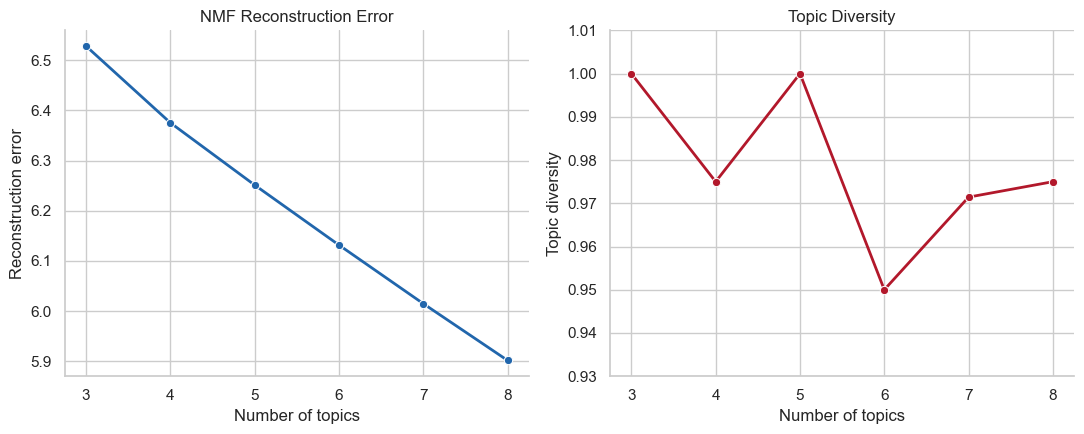

Saved: ..\outputs\nmf_candidate_diagnostics.svg


In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5)
)

# Reconstruction error
sns.lineplot(
    data=refined_nmf_evaluation,
    x="number_of_topics",
    y="reconstruction_error",
    marker="o",
    linewidth=2,
    color="#2166AC",
    ax=axes[0]
)

axes[0].set_title("NMF Reconstruction Error")
axes[0].set_xlabel("Number of topics")
axes[0].set_ylabel("Reconstruction error")
axes[0].set_xticks(
    refined_nmf_evaluation["number_of_topics"]
)

# Topic diversity
sns.lineplot(
    data=refined_nmf_evaluation,
    x="number_of_topics",
    y="topic_diversity",
    marker="o",
    linewidth=2,
    color="#B2182B",
    ax=axes[1]
)

axes[1].set_title("Topic Diversity")
axes[1].set_xlabel("Number of topics")
axes[1].set_ylabel("Topic diversity")
axes[1].set_xticks(
    refined_nmf_evaluation["number_of_topics"]
)
axes[1].set_ylim(0.93, 1.01)

sns.despine()
plt.tight_layout()

diagnostic_figure_path = (
    OUTPUT_DIR / "nmf_candidate_diagnostics.svg"
)

plt.savefig(
    diagnostic_figure_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("Saved:", diagnostic_figure_path)

In [ ]:
topic_support_rows = []

for number_of_topics in range(5, 9):

    document_topic_weights = (
        refined_document_topics[number_of_topics]
    )

    topic_term_weights = (
        refined_topic_terms[number_of_topics]
    )

    # Convert each document's topic weights into proportions
    row_totals = document_topic_weights.sum(
        axis=1,
        keepdims=True
    )

    document_topic_proportions = np.divide(
        document_topic_weights,
        row_totals,
        out=np.zeros_like(document_topic_weights),
        where=row_totals != 0
    )

    dominant_topics = (
        document_topic_proportions.argmax(axis=1)
    )

    for topic_index in range(number_of_topics):

        topic_weights = document_topic_weights[
            :,
            topic_index
        ]

        total_topic_weight = topic_weights.sum()

        # Effective number of contributing documents
        effective_document_count = (
            total_topic_weight ** 2
            / np.square(topic_weights).sum()
        )

        # Share of the topic contributed by its strongest document
        largest_document_share = (
            topic_weights.max()
            / total_topic_weight
        )

        top_indices = topic_term_weights[
            topic_index
        ].argsort()[-10:][::-1]

        top_terms = topic_model_terms[top_indices]

        topic_support_rows.append({
            "number_of_topics": number_of_topics,
            "topic": topic_index + 1,
            "dominant_document_count": int(
                (dominant_topics == topic_index).sum()
            ),
            "documents_with_at_least_10_percent": int(
                (
                    document_topic_proportions[
                        :,
                        topic_index
                    ] >= 0.10
                ).sum()
            ),
            "effective_document_count": round(
                effective_document_count,
                2
            ),
            "largest_document_share": round(
                largest_document_share,
                3
            ),
            "top_terms": ", ".join(top_terms)
        })

topic_support = pd.DataFrame(
    topic_support_rows
)

display(topic_support)

topic_support.to_csv(
    OUTPUT_DIR / "nmf_candidate_topic_support.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
selected_number_of_topics = 8

selected_model = refined_nmf_models[
    selected_number_of_topics
]

selected_document_topic_weights = (
    refined_document_topics[
        selected_number_of_topics
    ]
)

selected_topic_term_weights = (
    refined_topic_terms[
        selected_number_of_topics
    ]
)

# --------------------------------------------------
# Convert NMF weights to within-document proportions
# --------------------------------------------------

document_weight_totals = (
    selected_document_topic_weights
    .sum(axis=1, keepdims=True)
)

document_topic_proportions = np.divide(
    selected_document_topic_weights,
    document_weight_totals,
    out=np.zeros_like(
        selected_document_topic_weights
    ),
    where=document_weight_totals != 0
)

topic_columns = [
    f"topic_{topic_number}"
    for topic_number in range(
        1,
        selected_number_of_topics + 1
    )
]

document_topic_table = pd.DataFrame(
    document_topic_proportions,
    columns=topic_columns
)

document_topic_table.insert(
    0,
    "doc_id",
    public_modelling_data["doc_id"].to_numpy()
)

# Identify the dominant topic in every document
document_topic_table["dominant_topic"] = (
    document_topic_proportions.argmax(axis=1) + 1
)

document_topic_table["dominant_topic_proportion"] = (
    document_topic_proportions.max(axis=1)
)

# --------------------------------------------------
# Attach available document metadata
# --------------------------------------------------

metadata_candidates = [
    "doc_id",
    "title",
    "source_type",
    "publisher",
    "url"
]

available_metadata = [
    column
    for column in metadata_candidates
    if column in public_modelling_data.columns
]

document_topic_table = (
    document_topic_table
    .merge(
        public_modelling_data[
            available_metadata
        ].drop_duplicates(subset="doc_id"),
        on="doc_id",
        how="left",
        validate="one_to_one"
    )
)

# --------------------------------------------------
# Find the five strongest documents for each topic
# --------------------------------------------------

representative_document_rows = []

for topic_number in range(
    1,
    selected_number_of_topics + 1
):
    topic_column = f"topic_{topic_number}"

    strongest_documents = (
        document_topic_table
        .nlargest(5, topic_column)
        .copy()
    )

    strongest_documents["topic"] = topic_number
    strongest_documents["topic_proportion"] = (
        strongest_documents[topic_column]
    )
    strongest_documents["rank_within_topic"] = (
        range(1, 6)
    )

    representative_document_rows.append(
        strongest_documents
    )

representative_documents = pd.concat(
    representative_document_rows,
    ignore_index=True
)

display_columns = [
    column
    for column in [
        "topic",
        "rank_within_topic",
        "doc_id",
        "topic_proportion",
        "dominant_topic",
        "source_type",
        "title",
        "url"
    ]
    if column in representative_documents.columns
]

display(
    representative_documents[
        display_columns
    ]
)

# Save the results
document_topic_table.to_csv(
    OUTPUT_DIR / "nmf_8_topic_document_proportions.csv",
    index=False,
    encoding="utf-8-sig"
)

representative_documents[
    display_columns
].to_csv(
    OUTPUT_DIR / "nmf_8_topic_representative_documents.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
final_topic_labels = {
    1: "Urban and economic impacts",
    2: "Child vulnerability and protective action",
    3: "Age-specific exposure and cumulative heat stress",
    4: "Heatwave-related school closures",
    5: "Heat-health prevention and medical advice",
    6: "Compound climate hazards and educational disruption",
    7: "Maternal and newborn health risks",
    8: "Child growth, nutrition and long-term development"
}

dominant_topic_indices = (
    document_topic_proportions.argmax(axis=1)
)

topic_prevalence_rows = []

for topic_number in range(
    1,
    selected_number_of_topics + 1
):
    topic_index = topic_number - 1

    topic_prevalence_rows.append({
        "topic": topic_number,
        "topic_label": final_topic_labels[
            topic_number
        ],
        "mean_normalized_weight": (
            document_topic_proportions[
                :,
                topic_index
            ].mean()
        ),
        "dominant_document_count": int(
            (
                dominant_topic_indices
                == topic_index
            ).sum()
        ),
        "documents_with_at_least_10_percent": int(
            (
                document_topic_proportions[
                    :,
                    topic_index
                ] >= 0.10
            ).sum()
        )
    })

topic_prevalence = pd.DataFrame(
    topic_prevalence_rows
)

topic_prevalence["mean_weight_percentage"] = (
    topic_prevalence["mean_normalized_weight"]
    * 100
)

topic_prevalence = (
    topic_prevalence
    .sort_values(
        "mean_normalized_weight",
        ascending=False
    )
    .reset_index(drop=True)
)

display(topic_prevalence)

print(
    "Total mean normalized weight:",
    topic_prevalence[
        "mean_normalized_weight"
    ].sum()
)

In [ ]:
plot_data = (
    topic_prevalence
    .sort_values(
        "mean_weight_percentage",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

sns.barplot(
    data=plot_data,
    x="mean_weight_percentage",
    y="topic_label",
    color="#2F6B8A",
    ax=ax
)

ax.bar_label(
    ax.containers[0],
    labels=[
        f"{value:.1f}%"
        for value in plot_data[
            "mean_weight_percentage"
        ]
    ],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Prevalence of Topics in Public-Facing Documents",
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    "Mean normalized topic weight (%)"
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    plot_data[
        "mean_weight_percentage"
    ].max() * 1.18
)

sns.despine(
    left=True,
    bottom=False
)

plt.tight_layout()

topic_figure_path = (
    OUTPUT_DIR / "nmf_topic_prevalence.svg"
)

plt.savefig(
    topic_figure_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("Saved:", topic_figure_path)

topic_prevalence.to_csv(
    OUTPUT_DIR / "nmf_8_topic_prevalence.csv",
    index=False,
    encoding="utf-8-sig"
)